# Pattern-CA repair on real sandstone — statistical validation

**The question:** if we take a real rock slice, add noise, and repair it, is the
result *statistically* the same rock — not pixel-identical, but drawn from the same
underlying microstructure?

**Why pixels are the wrong test.** Real slices of the same rock are all different
images yet share the same statistics. So a good repair need not match any slice
pixel-for-pixel; it must land inside the *statistical family* the real slices define.
We measure that family with the descriptor suite (proportion, S2, Fourier, wavelets,
persistence, Minkowski/Euler).

**Plan:**
1. Load several real Bentheimer slices — all different, same material.
2. Fingerprint them → this spread *is* "same underlying statistics".
3. Take one slice, add noise, repair it.
4. Check the repaired fingerprint falls inside the real spread — not just looks right.

Uses:
- `pattern_ca.py` — learned-vocabulary repair + speck / connectivity cleanup
- `descriptors.py` — the scoring suite + PCA

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import gzip

import pattern_ca as P
import descriptors as D

## 1. Load several real rock slices
Different slices of the 1000³ volume: all different images, all the same rock.
This spread defines "same underlying statistics".

5 real slices, each (512, 512)
porosities: [0.2188, 0.1815, 0.2184, 0.1878, 0.2383]


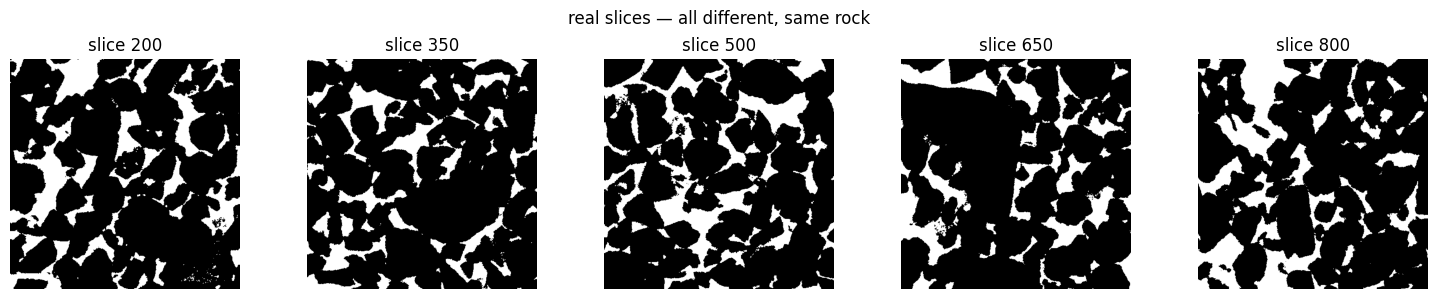

In [11]:
RAW = "Bentheimer_1000c_3p0035um.raw.gz"   # <-- match your filename
SLICE_IDS = [200, 350, 500, 650, 800]      # a spread of depths through the volume
CROP = (slice(128, 128+512), slice(0, 512))

def load_volume(path):
    with gzip.open(path, "rb") as fh:
        return np.frombuffer(fh.read(), dtype=np.uint8).reshape(1000, 1000, 1000)

try:
    real_slices = [np.load(f"bentheimer_slice_{i}.npy") for i in SLICE_IDS]
except FileNotFoundError:
    vol = load_volume(RAW)
    real_slices = []
    for i in SLICE_IDS:
        crop = vol[i][CROP]
        s = (crop == 0).astype(int)            # pore -> 1
        np.save(f"bentheimer_slice_{i}.npy", s)
        real_slices.append(s)

print(f"{len(real_slices)} real slices, each {real_slices[0].shape}")
print("porosities:", [round(float(s.mean()), 4) for s in real_slices])

fig, ax = plt.subplots(1, len(real_slices), figsize=(3*len(real_slices), 3))
for a, (i, s) in zip(ax, zip(SLICE_IDS, real_slices)):
    a.imshow(s, cmap="gray", vmin=0, vmax=1); a.set_title(f"slice {i}"); a.axis("off")
fig.suptitle("real slices — all different, same rock"); plt.tight_layout(); plt.show()

## 2. Fingerprint the real slices → the statistical family
Each slice becomes one row of descriptor numbers. The **spread** across slices is
the natural variation of the real rock — the target any repair must fall inside.

In [12]:
real_fps = [D.describe(s, verbose=False) for s in real_slices]
labels = list(real_fps[0].keys())
real_mat = np.array([[fp[k] for k in labels] for fp in real_fps])

real_mean = real_mat.mean(0)
real_std  = real_mat.std(0)

print(f"{'descriptor':22s} {'real mean':>12s} {'real std':>10s}")
for k, mu, sd in zip(labels, real_mean, real_std):
    print(f"{k:22s} {mu:12.4f} {sd:10.4f}")

descriptor                real mean   real std
low_proportion               0.2090     0.0212
low_interface                0.0235     0.0019
low_corr_len                 9.8000     0.7483
fourier_char_freq            6.6529     1.0060
fourier_slope               -2.3076     0.0200
wave_level1_total         7777.4810   674.3986
wave_level1_imbalance        0.4312     0.0116
wave_level2_total         3972.9392   381.0270
wave_level2_imbalance        0.4341     0.0075
wave_level3_total         2201.6749   177.9724
wave_level3_imbalance        0.3823     0.0078
wave_level4_total         1958.7559   153.2944
wave_level4_imbalance        0.2444     0.0090
pers_blobs_H0_n             37.0000    11.5412
pers_blobs_H0_maxlife        0.9147     0.1638
pers_holes_H1_n            486.4000    77.3579
pers_holes_H1_maxlife        1.0000     0.0000
mink_area                    0.2090     0.0212
mink_perimeter               0.0470     0.0037
mink_euler                  97.2000    15.3154


## 3. Add noise to one slice and repair it

patterns=345  wrong (pixel): 10.0% -> 0.9%


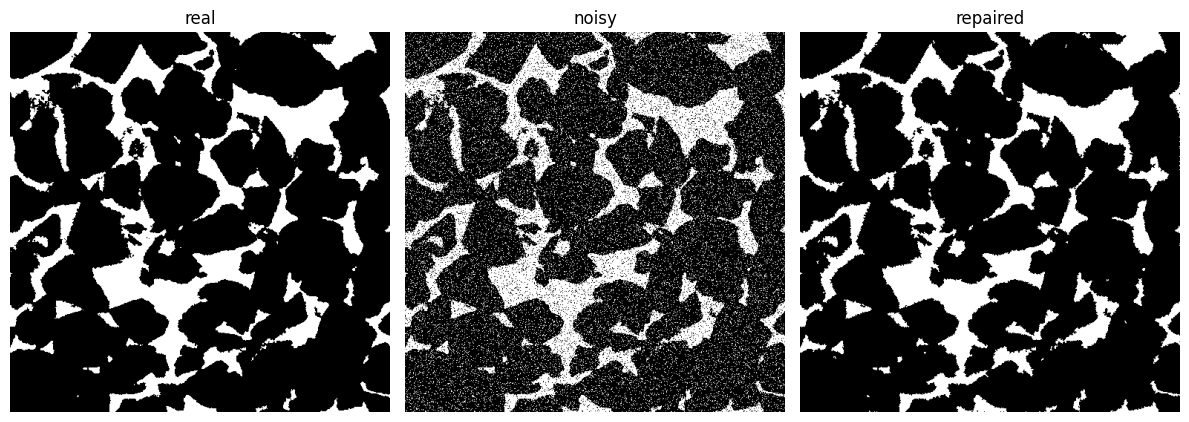

In [33]:
def add_noise(field, frac, seed=1):
    rng = np.random.default_rng(seed)
    out = field.copy(); out[rng.random(field.shape) < frac] ^= 1
    return out

def repair(truth, noise, radius=1, sweeps=100, seed=1, min_size=6, preclean=True):
    """Repair a noisy copy: pre-clean, CA, speck cleanup, connectivity cleanup."""
    seen = P.build_windows_periodic(truth, radius=radius)
    pats = P.pattern_array(seen, radius=radius)
    noisy = add_noise(truth, noise, seed=seed)
    out = P.run_sync(P.clean_specks(noisy), seen, pats, mode="hybrid",
                     radius=radius, sweeps=sweeps, verbose=False)
    out = P.clean_specks(out)
    out = P.remove_small_blobs(out, min_size=min_size)   # clears edge-hugging specks
    print(f"patterns={len(seen)}  wrong (pixel): {(noisy!=truth).mean():.1%} -> {(out!=truth).mean():.1%}")
    return noisy, out

target = real_slices[2]                        # the slice we corrupt + repair
noisy, repaired = repair(target, noise=0.1, radius=1, sweeps=100, min_size=6)

fig, ax = plt.subplots(1, 3, figsize=(12, 4.2))
for a, (t, im) in zip(ax, [("real", target), ("noisy", noisy), ("repaired", repaired)]):
    a.imshow(im, cmap="gray", vmin=0, vmax=1); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

## 4. Does the repaired slice fall inside the real family?
Not "does it match pixel-for-pixel" — but is each descriptor within the natural
spread of the real slices? We report a **z-score**: how many real-slice standard
deviations the repaired value sits from the real mean. |z| < ~2 = indistinguishable
from a real slice on that measure; large |z| = the repair stands out (usually the
tiny-speck problem showing up in Euler / perimeter / blob counts).

In [14]:
rep_fp = D.describe(repaired, verbose=False)
rep_vec = np.array([rep_fp[k] for k in labels])
z = (rep_vec - real_mean) / np.where(real_std > 0, real_std, 1)

print(f"{'descriptor':22s} {'real mean':>10s} {'repaired':>10s} {'z':>7s}")
for k, mu, rv, zz in zip(labels, real_mean, rep_vec, z):
    flag = "  <-- outside" if abs(zz) > 2 else ""
    print(f"{k:22s} {mu:10.4f} {rv:10.4f} {zz:7.2f}{flag}")

inside = np.sum(np.abs(z) <= 2)
print(f"\n{inside}/{len(labels)} descriptors within 2 sd of the real family")

descriptor              real mean   repaired       z
low_proportion             0.2090     0.2201    0.53
low_interface              0.0235     0.0321    4.61  <-- outside
low_corr_len               9.8000     9.0000   -1.07
fourier_char_freq          6.6529     7.5378    0.88
fourier_slope             -2.3076    -2.1568    7.56  <-- outside
wave_level1_total       7777.4810  8809.3781    1.53
wave_level1_imbalance      0.4312     0.4342    0.26
wave_level2_total       3972.9392  4538.9420    1.49
wave_level2_imbalance      0.4341     0.4293   -0.65
wave_level3_total       2201.6749  2716.3325    2.89  <-- outside
wave_level3_imbalance      0.3823     0.3629   -2.51  <-- outside
wave_level4_total       1958.7559  2795.6876    5.46  <-- outside
wave_level4_imbalance      0.2444     0.2025   -4.66  <-- outside
pers_blobs_H0_n           37.0000   103.0000    5.72  <-- outside
pers_blobs_H0_maxlife      0.9147     0.9964    0.50
pers_holes_H1_n          486.4000   749.0000    3.39  <-- out

## 5. PCA: repaired vs the real cloud
Stack all real slices + the repaired one, PCA to 2D. If the repair is statistically
the same rock, the repaired point lands **inside the cloud** of real slices. A point
sitting apart means it's distinguishable from real — the eye-vs-statistics gap.

variance explained:
  PC1:  57.7%
      low_interface                -0.301
      mink_perimeter               -0.301
      wave_level4_total            -0.299
      wave_level4_imbalance        +0.298
  PC2:  20.0%
      mink_area                    -0.459
      low_proportion               -0.459
      fourier_char_freq            +0.440
      pers_blobs_H0_maxlife        -0.403


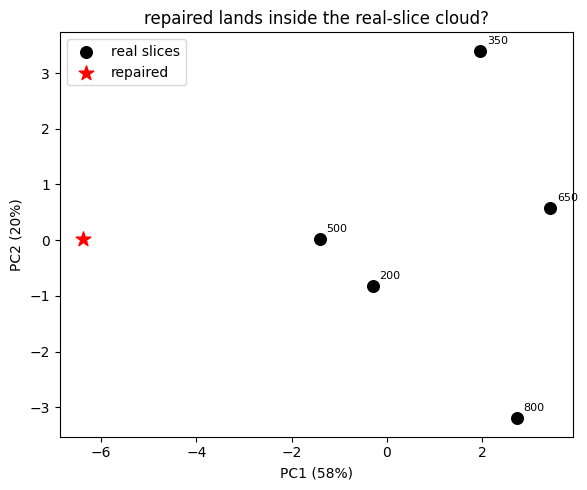

In [15]:
all_mat = np.vstack([real_mat, rep_vec])
scores, var = D.pca_suite(all_mat, labels, n_components=2, verbose=True)

plt.figure(figsize=(6, 5))
plt.scatter(scores[:-1, 0], scores[:-1, 1], c="k", s=70, label="real slices")
plt.scatter(scores[-1, 0], scores[-1, 1], c="r", s=120, marker="*", label="repaired")
for i, sid in enumerate(SLICE_IDS):
    plt.annotate(str(sid), (scores[i, 0], scores[i, 1]), fontsize=8,
                 textcoords="offset points", xytext=(5, 5))
plt.xlabel(f"PC1 ({var[0]*100:.0f}%)"); plt.ylabel(f"PC2 ({var[1]*100:.0f}%)")
plt.title("repaired lands inside the real-slice cloud?")
plt.legend(); plt.tight_layout(); plt.show()